# Fused RMSNorm & Residual Add in Triton
Colab notebook for the GPU environment

_*Use a GPU runtime_

Clone the repository

In [1]:
import os
import shutil

repo_url = "https://github.com/jarnesino/fused-rmsnorm-residual-add-triton.git"
repo_dir = "/content/fused-rmsnorm-residual-add-triton"

# Remove existing clone
%cd /content
if os.path.exists(repo_dir):
    shutil.rmtree(repo_dir)

# Clone again
!git clone "$repo_url" "$repo_dir"

/content
Cloning into '/content/fused-rmsnorm-residual-add-triton'...
remote: Enumerating objects: 424, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 424 (delta 53), reused 180 (delta 31), pack-reused 218 (from 1)
Receiving objects: 100% (424/424), 2.72 MiB | 27.08 MiB/s, done.
Resolving deltas: 100% (200/200), done.


Set up the environment

In [2]:
%cd /content/fused-rmsnorm-residual-add-triton
!curl -LsSf https://astral.sh/uv/install.sh | sh
!pip install -q go-task-bin
!task gpu:sync
!task gpu:test

/content/fused-rmsnorm-residual-add-triton
downloading uv 0.12.18 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 102.0 MB/s eta 0:00:00
task: [gpu:sync] uv sync --frozen --extra cu128 --extra bench
Using CPython 3.13.15 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Prepared 69 packages in 1m 15s
Installed 69 packages in 548ms
 + annotated-doc==0.0.5
 + anyio==4.15.1
 + certifi==2026.7.22
 + click==8.5.0
 + contourpy==1.3.3
 + cuda-bindings==12.9.7
 + cuda-pathfinder==1.8.1
 + cuda-toolkit==12.8.1
 + cycler==0.12.1
 + filelock==3.32.5
 + fonttools==4.64.0
 + fsspec==2026.7.0
 + fused-rmsnorm-residual-add==0.1.0 (from file:///content/fused-rmsnorm-residual-add-triton)
 + h11==0.16.0
 + hf-xet==1.6.0
 + httpcore==1.0.9
 + httpx==0.28.1
 + huggingface-hub==1.31.0
 + idna==3.19
 + iniconfig==2.3.0
 + jinja2==3.1.6
 + kiwisolver==1.5.1
 + liger-kernel==0.8.2
 + markdow

In [3]:
os.environ["MPLBACKEND"] = "agg"

from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image as ImageDisplay
from PIL import Image

Run tutorial benchmarks

In [4]:
!task gpu:bench:tutorials

task: [gpu:bench:tutorials] uv run python benchmarks/tutorials/bench_softmax.py
softmax-bandwidth:
    number_of_columns  Triton (one program per row) (GB/s)  Triton (persistent grid) (GB/s)  Torch (GB/s)  Naive (GB/s)
0               256.0                           173.319816                       147.176118    206.694965     53.689868
1               384.0                           226.452824                       213.270398    216.537358     54.687812
2               512.0                           220.365661                       214.581162    215.936300     55.298636
3               640.0                           225.119689                       218.569533    215.215239     56.104711
4               768.0                           226.637463                       218.749460    213.819808     56.837826
5               896.0                           226.760981                       219.864710    211.424166     57.232218
6              1024.0                           228.020439   

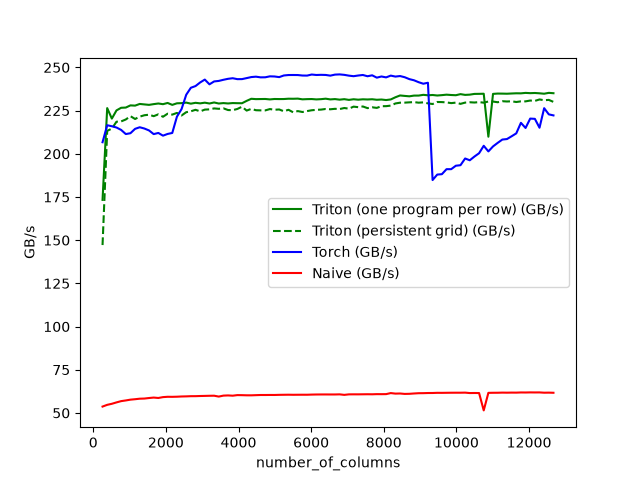

In [5]:
ImageDisplay("benchmarks/results/softmax/softmax-bandwidth.png")

Run RMSNormResidualAdd benchmarks

In [6]:
!TRITON_PRINT_AUTOTUNING=1 task gpu:bench -- --runs 3

task: [gpu:bench] uv run python benchmarks/bench_rms_norm_residual_add.py --runs 3
Autotuning kernel fused_rmsnorm_residual_add_kernel with config programs_per_sm: 0, num_warps: 1, num_ctas: 1, num_stages: 1, maxnreg: None
Autotuning kernel fused_rmsnorm_residual_add_kernel with config programs_per_sm: 1, num_warps: 1, num_ctas: 1, num_stages: 1, maxnreg: None
Autotuning kernel fused_rmsnorm_residual_add_kernel with config programs_per_sm: 2, num_warps: 1, num_ctas: 1, num_stages: 1, maxnreg: None
Autotuning kernel fused_rmsnorm_residual_add_kernel with config programs_per_sm: 4, num_warps: 1, num_ctas: 1, num_stages: 1, maxnreg: None
Autotuning kernel fused_rmsnorm_residual_add_kernel with config programs_per_sm: 8, num_warps: 1, num_ctas: 1, num_stages: 1, maxnreg: None
Autotuning kernel fused_rmsnorm_residual_add_kernel with config programs_per_sm: 16, num_warps: 1, num_ctas: 1, num_stages: 1, maxnreg: None
Autotuning kernel fused_rmsnorm_residual_add_kernel with config programs_per

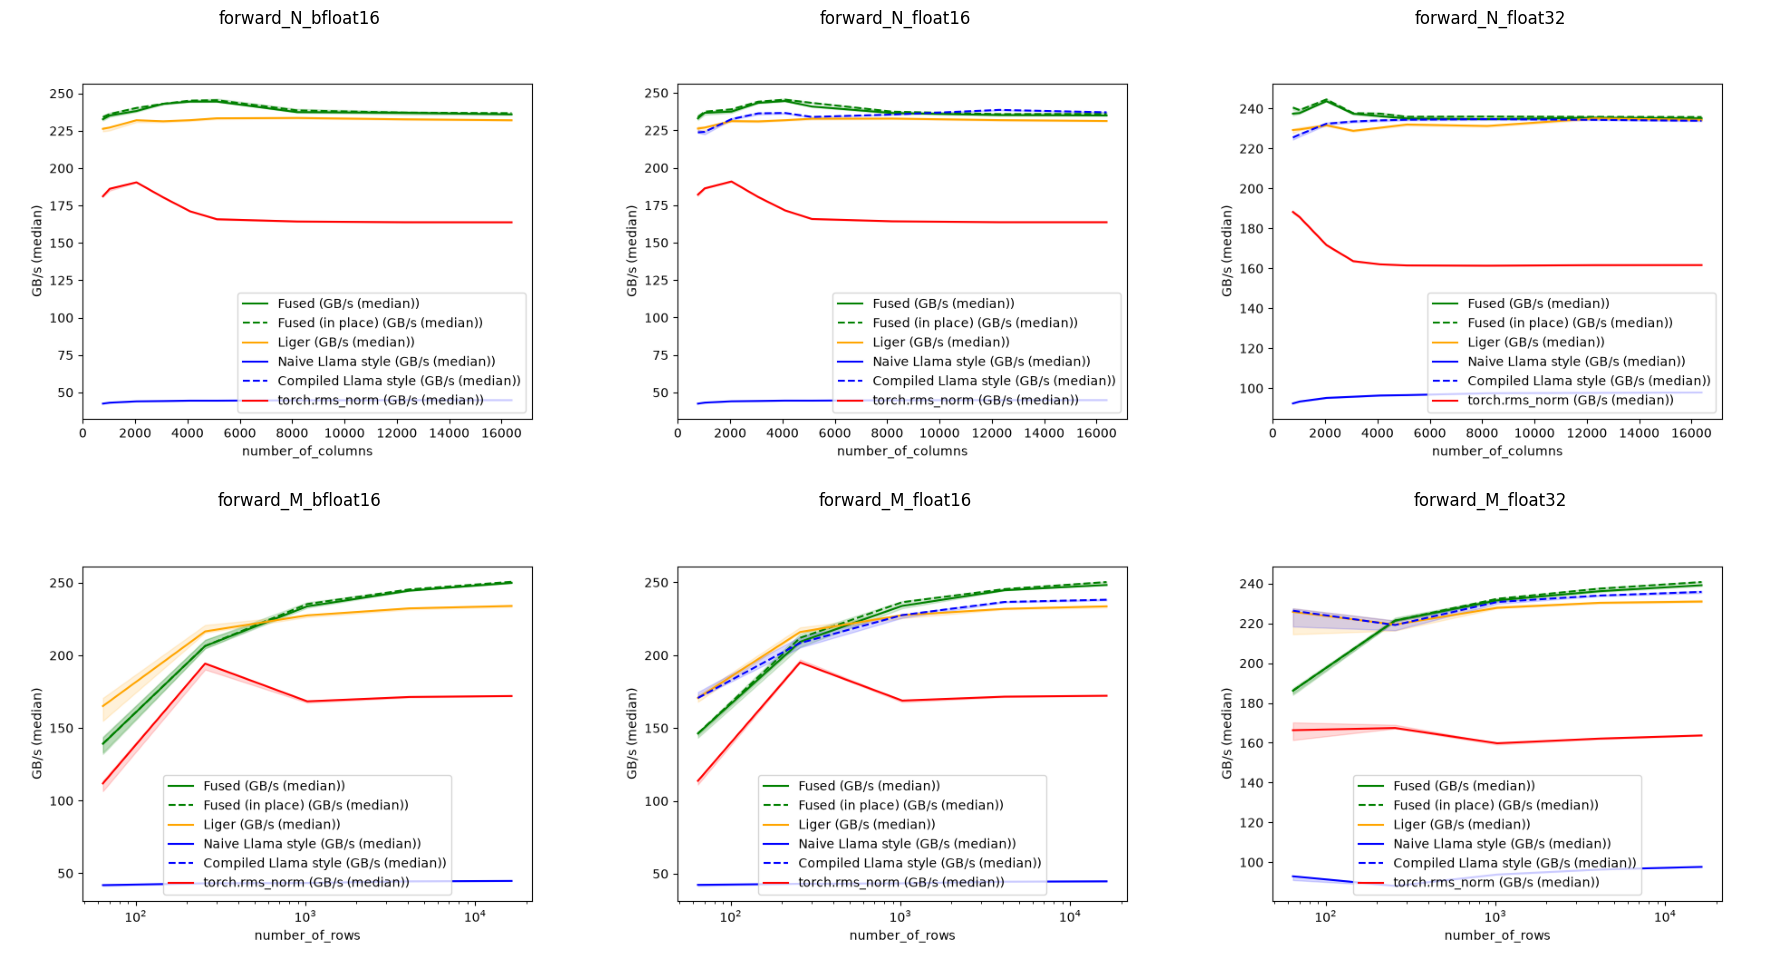

In [7]:
base = Path("benchmarks/results/tesla-t4")
latest = max(p for p in base.iterdir() if p.is_dir())

paths = [
    str(latest / f"forward_{axis}_{dtype}.png")
    for axis in ("N", "M")
    for dtype in ("bfloat16", "float16", "float32")
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, path in zip(axes.flat, paths, strict=True):
    ax.imshow(Image.open(path))
    ax.set_title(path.split("/")[-1].replace(".png", ""))
    ax.axis("off")

plt.tight_layout()
plt.show()

Download results

In [8]:
!cd benchmarks/results && zip -qr /content/results-tesla-t4.zip tesla-t4
from google.colab import files

files.download("/content/results-tesla-t4.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# PTX and register inspection

Machine data

In [9]:
%%bash
cd "${REPOSITORY:-/content/fused-rmsnorm-residual-add-triton}"
uv run python - <<'PY'
import subprocess
import torch
import triton

commit = subprocess.run(
    ["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True
).stdout.strip()
dirty = subprocess.run(
    ["git", "status", "--porcelain", "--untracked-files=no"], capture_output=True, text=True
).stdout.strip()

print("gpu:     ", torch.cuda.get_device_name(0))
print("torch:   ", torch.__version__)
print("triton:  ", triton.__version__)
print("cuda:    ", torch.version.cuda)
print("commit:  ", commit, "(dirty)" if dirty else "")
PY

gpu:      Tesla T4
torch:    2.11.0+cu128
triton:   3.6.0
cuda:     12.8
commit:   9893586 


## 1. Vector widths in the PTX

The autotuner compiles every config that survives pruning, and each compiled
config is dumped to its own directory, so the grep below prints one block per
config (not per kernel).

Is the config vectorizing?
- `ld.global.v4.b32` / `st.global.v4.b32` means 16 bytes
- `ld.global.v2.b32` / `st.global.v2.b32` means 8 bytes
- `.b16` means no vectorization

In [10]:
%%bash
cd "${REPOSITORY:-/content/fused-rmsnorm-residual-add-triton}"

DUMP_DIR="${TRITON_DUMP_DIR:-/content/dump}"
rm -rf "$DUMP_DIR"

export TRITON_KERNEL_DUMP=1
export TRITON_DUMP_DIR="$DUMP_DIR"
export TRITON_ALWAYS_COMPILE=1

uv run python - <<'PY'
import torch
from fused_rmsnorm_residual_add.fused import FusedImplementation

number_of_rows, number_of_columns = 4096, 4096
x = torch.randn(number_of_rows, number_of_columns, device="cuda", dtype=torch.bfloat16)
residual = torch.randn_like(x)
weight = torch.randn(number_of_columns, device="cuda", dtype=torch.bfloat16)

FusedImplementation(weight, 1e-6).forward(x, residual)
PY

for directory in "$DUMP_DIR"/*/; do
  echo "== $(basename "$directory")"
  grep -o 'ld\.global[a-z0-9.]*\|st\.global[a-z0-9.]*' "$directory"*.ptx \
    | sort | uniq -c | sort -rn
done

== BO4NBQ2A24KSLWHKLQREAQ7LINYRFV45BHC7IGEGK62VKYQ5RCQA
      6 ld.global.v4.b32
      4 st.global.v4.b32
== FRXEHNJMOSRDY2BTJDS7K72DU6U447FTTUHGIKDJJVQLIR2P5UMQ
      3 ld.global.v2.b32
      2 st.global.v2.b32
== KXESZS72FBC2OX43FQAWV5JUA4DEKP7ONHUSHX2WW562XLVLQNCA
     24 ld.global.v4.b32
     16 st.global.v4.b32
== MU3FC4EMCUHJRAZLFLE6MOPHYNDAEWIBKB54WY7BQNFWEAB7S7CA
     12 ld.global.v4.b32
      8 st.global.v4.b32
== QEC2NT325OZTO2KADIL4YUMXSIAVZOFVOF7KSZMXHPNXC3UPR27Q
      3 ld.global.v4.b32
      2 st.global.v4.b32
== UE7532D2L4VJBM6GZRIF4676PPN4B2JL4VME5U5JQ2FLQ4KIY47A
      3 ld.global.v2.b32
      2 st.global.v2.b32


## 2. Register pressure and the prune ceiling

N=16384 has the whole range the prune has to cover, with 512 elements per thread
at 1 warp, down to 16 at 32 warps.

`n_spills` means local-memory bytes per thread.

When does loweing the number of warps stop getting wider loads?

In [11]:
%%bash
cd "${REPOSITORY:-/content/fused-rmsnorm-residual-add-triton}"
uv run python - <<'PY'
import torch
from fused_rmsnorm_residual_add import fused

number_of_rows, number_of_columns = 1024, 16384
x = torch.randn(number_of_rows, number_of_columns, device="cuda", dtype=torch.bfloat16)
residual = torch.randn_like(x)
weight = torch.randn(number_of_columns, device="cuda", dtype=torch.bfloat16)

fused.FusedImplementation(weight, 1e-6).forward(x, residual)

kernel = fused.fused_rmsnorm_residual_add_kernel
try:
    device_cache = kernel.fn.device_caches[torch.cuda.current_device()][0]
except (AttributeError, KeyError, IndexError) as error:
    raise RuntimeError(
        "Could not reach Triton's compiled-kernel cache. This relies on Triton "
        "internals, verified against triton 3.6.0. Try: "
        "cuobjdump -res-usage on the compiled binary."
    ) from error

compiled_by_warps = {
    compiled.metadata.num_warps: compiled for compiled in device_cache.values()
}

block_size = number_of_columns
print(f"{'warps':>5} {'elems/thread':>13} {'registers':>10} {'spill bytes':>12}")
for number_of_warps, compiled in sorted(compiled_by_warps.items()):
    elements_per_thread = block_size // (32 * number_of_warps)
    print(
        f"{number_of_warps:>5} {elements_per_thread:>13} "
        f"{compiled.n_regs:>10} {compiled.n_spills:>12}"
    )
PY

warps  elems/thread  registers  spill bytes
    8            64        128            0
   16            32         64            4
   32            16         57            0


`elements_per_thread = BLOCK_N / (32 × num_warps)`

Below 4 warps each thread holds too much state and spills to local memory, when the point is avoiding memory traffic. Above 16 warps each thread no longer holds 16 contiguous bytes, so the compiler drops from ld.global.v4.b32 to 8-byte accesses.